In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


# Smart MCQ Solver - Exploratory Data Analysis

This notebook performs exploratory data analysis on the Smart MCQ Solver Challenge dataset.


In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

plt.style.use("ggplot")
pd.set_option("display.max_colwidth", 500)

In [3]:
train = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")
sample = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv")

print("Train Shape:", train.shape)
print("Test Shape :", test.shape)
print("Sample Shape:", sample.shape)

Train Shape: (2000, 8)
Test Shape : (500, 7)
Sample Shape: (500, 2)


In [4]:
display(train.head())

print("\nColumns:")
print(train.columns.tolist())

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.,"Martin Heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. The relationship to the past involves acknowledging it as a historical era, and the relationship to the future involves creating a world that will endure beyond one's own time.","Martin Heidegger believes that humans do not exist inside time, but that they are time. The relationship to the past is a present awareness of having been, and the relationship to the future involves anticipating a potential possibility, task, or engagement.","Martin Heidegger does not believe in the existence of time or that it has any effect on human consciousness. The relationship to the past and the future is insignificant, and human existence is solely based on the present.",Martin Heidegger believes that the relationship between time and human existence is cyclical. The past and present are interconnected and the future is predetermined. Human beings do not have free will.,"Martin Heidegger believes that time is an illusion, and the past, present, and future are all happening simultaneously. Humans exist outside of this illusion and are guided by a higher power.",B
1,2,What is accelerator-based light-ion fusion?,"Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-ion fusion reactions. This method is relatively easy to implement and can be done in an efficient manner, requiring only a vacuum tube, a pair of electrodes, and a high-voltage transformer. Fusion can be observed with as little as 10 kV between the electrodes.","Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce heavy-ion fusion reactions. This method is relatively difficult to implement and requires a complex system of vacuum tubes, electrodes, and transformers. Fusion can be observed with as little as 10 kV between the electrodes.","Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-ion fusion reactions. This method is relatively difficult to implement and requires a complex system of vacuum tubes, electrodes, and transformers. Fusion can be observed with as little as 100 kV between the electrodes.","Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce heavy-ion fusion reactions. This method is relatively easy to implement and can be done in an efficient manner, requiring only a vacuum tube, a pair of electrodes, and a high-voltage transformer. Fusion can be observed with as little as 100 kV between the electrodes.","Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-ion fission reactions. This method is relatively easy to implement and can be done in an efficient manner, requiring only a vacuum tube, a pair of electrodes, and a high-voltage transformer. Fission can be observed with as little as 10 kV between the electrodes.",A
2,3,Determine the correct option: What is the term used in astrophysics to describe light-matter interactions resulting in energy shifts in the radiation field? among the listed options.,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Martin Heidegger's view on the relationship between time and human existence? carefully.,"Martin Heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. The relationship to the past involves acknowledging it as a historical era, and the relationship to the f


Columns:
['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer']


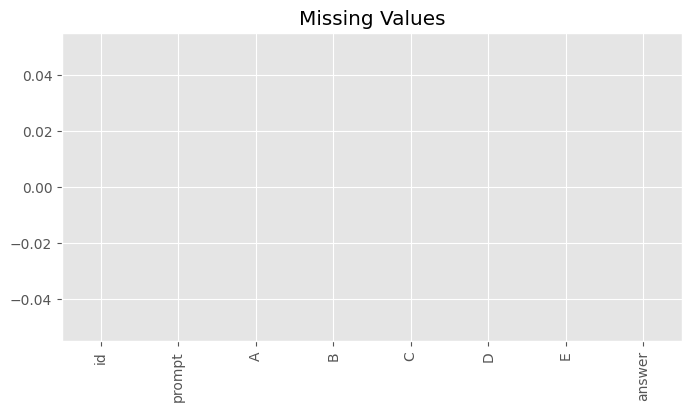

id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

In [5]:
missing = train.isnull().sum()

plt.figure(figsize=(8,4))
missing.plot(kind="bar")
plt.title("Missing Values")
plt.show()

missing

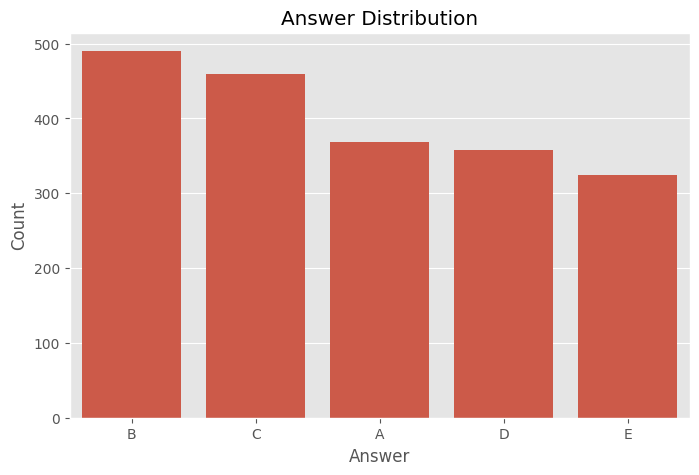

answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64

In [6]:
answer_counts = train["answer"].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(
    x=answer_counts.index,
    y=answer_counts.values
)

plt.title("Answer Distribution")
plt.xlabel("Answer")
plt.ylabel("Count")
plt.show()

answer_counts

## Observation

The dataset is mildly imbalanced.

Answer B appears most frequently while E appears least frequently.

Stratified validation should be used during training.

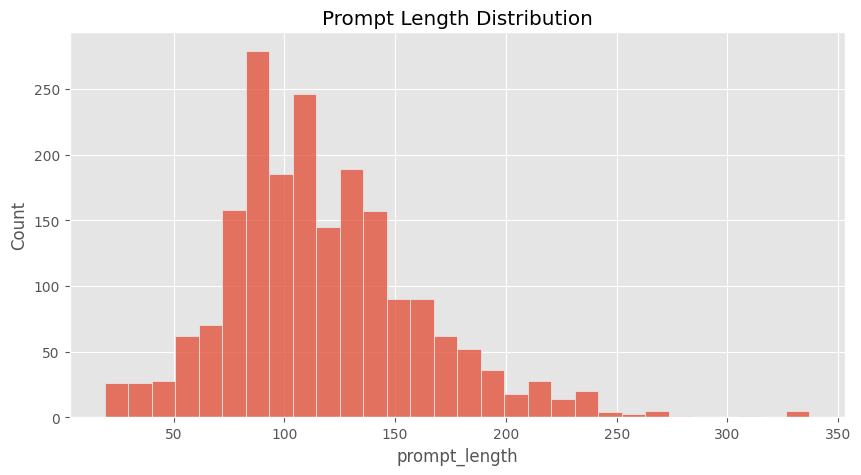

count    2000.000000
mean      117.669500
std        44.408674
min        19.000000
25%        87.750000
50%       111.000000
75%       141.000000
max       337.000000
Name: prompt_length, dtype: float64

In [7]:
train["prompt_length"] = train["prompt"].astype(str).str.len()

plt.figure(figsize=(10,5))
sns.histplot(
    train["prompt_length"],
    bins=30
)

plt.title("Prompt Length Distribution")
plt.show()

train["prompt_length"].describe()

In [8]:
for col in ["A","B","C","D","E"]:
    train[f"{col}_length"] = train[col].astype(str).str.len()

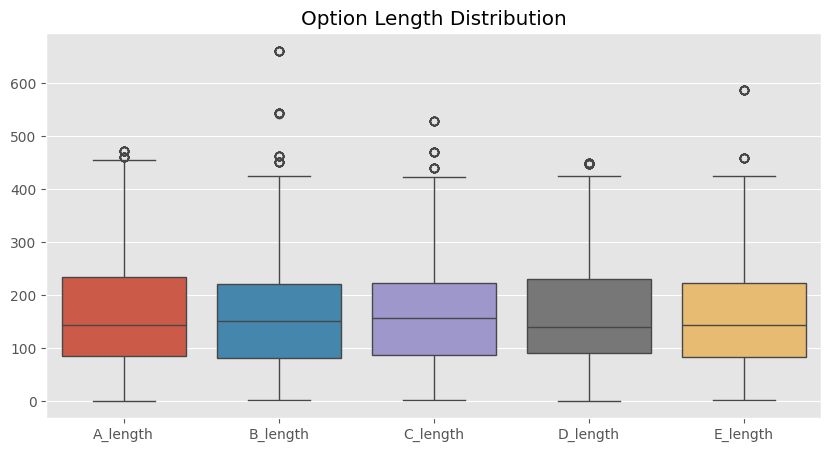

In [9]:
option_lengths = train[
    ["A_length","B_length","C_length","D_length","E_length"]
]

plt.figure(figsize=(10,5))

sns.boxplot(data=option_lengths)

plt.title("Option Length Distribution")
plt.show()

In [10]:
option_lengths.mean().sort_values(ascending=False)

C_length    167.2270
B_length    166.6165
E_length    164.2300
A_length    164.0915
D_length    162.5635
dtype: float64

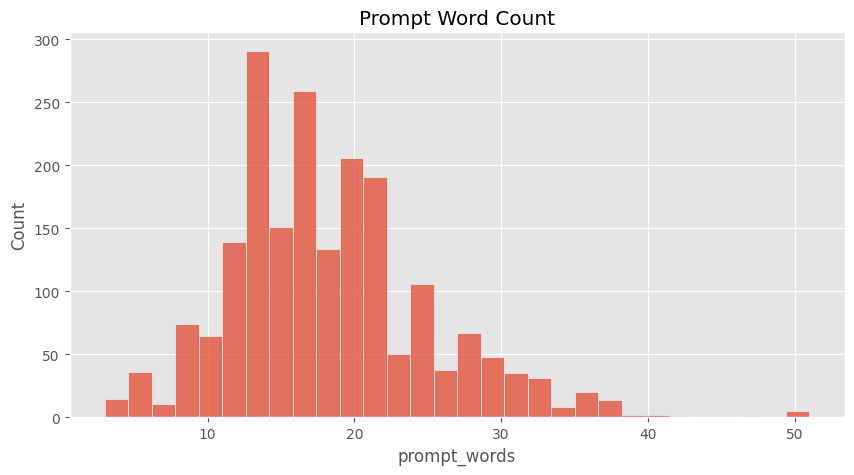

In [11]:
train["prompt_words"] = (
    train["prompt"]
    .astype(str)
    .str.split()
    .str.len()
)

plt.figure(figsize=(10,5))

sns.histplot(
    train["prompt_words"],
    bins=30
)

plt.title("Prompt Word Count")
plt.show()

In [12]:
duplicates = train["prompt"].duplicated().sum()

print("Duplicate Prompts:", duplicates)

Duplicate Prompts: 242


In [13]:
duplicate_examples = train[
    train["prompt"].duplicated(keep=False)
].sort_values("prompt")

duplicate_examples.head(20)

,id,prompt,A,B,C,D,E,answer,prompt_length,A_length,B_length,C_length,D_length,E_length,prompt_words
605,606,Choose the correct answer: What are permutation-inversion groups?,Permutation-inversion groups are groups of symmetry operations that are energetically feasible inversions of identical nuclei or rotation with respect to the center of mass.,"Permutation-inversion groups are groups of symmetry operations that are energetically feasible inversions of identical nuclei or rotation with respect to the center of mass, or a combination of both.",Permutation-inversion groups are groups of symmetry operations that are energetically feasible rotations of the entire molecule about the C3 axis.,Permutation-inversion groups are groups of symmetry operations that are energetically feasible inversions of the entire molecule about the C3 axis.,"Permutation-inversion groups are groups of symmetry operations that are energetically feasible permutations of identical nuclei or inversion with respect to the center of mass, or a combination of both.",E,65,173,199,146,147,202,8
456,457,Choose the correct answer: What are permutation-inversion groups?,Permutation-inversion groups are groups of symmetry operations that are energetically feasible inversions of identical nuclei or rotation with respect to the center of mass.,"Permutation-inversion groups are groups of symmetry operations that are energetically feasible inversions of identical nuclei or rotation with respect to the center of mass, or a combination of both.",Permutation-inversion groups are groups of symmetry operations that are energetically feasible rotations of the entire molecule about the C3 axis.,Permutation-inversion groups are groups of symmetry operations that are energetically feasible inversions of the entire molecule about the C3 axis.,"Permutation-inversion groups are groups of symmetry operations that are energetically feasible permutations of identical nuclei or inversion with respect to the center of mass, or a combination of both.",E,65,173,199,146,147,202,8
439,440,Choose the correct answer: What are permutation-inversion groups?,Permutation-inversion groups are groups of symmetry operations that are energetically feasible inversions of identical nuclei or rotation with respect to the center of mass.,"Permutation-inversion groups are groups of symmetry operations that are energetically feasible inversions of identical nuclei or rotation with respect to the center of mass, or a combination of both.",Permutation-inversion groups are groups of symmetry operations that are energetically feasible rotations of the entire molecule about the C3 axis.,Permutation-inversion groups are groups of symmetry operations that are energetically feasible inversions of the entire molecule about the C3 axis.,"Permutation-inversion groups are groups of symmetry operations that are energetically feasible permutations of identical nuclei or inversion with respect to the center of mass, or a combination of both.",E,65,173,199,146,147,202,8
1464,1465,Choose the correct answer: What are permutation-inversion groups? based on the given context.,Permutation-inversion groups are groups of symmetry operations that are energetically feasible inversions of identical nuclei or rotation with respect to the center of mass.,"Permutation-inversion groups are groups of symmetry operations that are energetically feasible inversions of identical nuclei or rotation with respect to the center of mass, or a combination of both.",Permutation-inversion groups are groups of symmetry operations that are energetically feasible rotations of the entire molecule about the C3 axis.,Permutation-inversion groups are groups of symmetry operations that are energetically feasible inversions of the entire molecule about the C3 axis.,"Permutation-inversion groups are groups of symmetry operations that are energetically feasible permutations of identical nuclei or inversion with respect to the center of mass, or a combination

In [14]:
dup = train.groupby("prompt")["answer"].nunique()

dup.sort_values(ascending=False).head(20)

prompt
Choose the correct answer: How do the Lunar Laser Ranging Experiment, radar astronomy, and the Deep Space Network determine distances to the Moon, planets, and spacecraft? among the listed options.      1
Choose the correct answer: How do the Lunar Laser Ranging Experiment, radar astronomy, and the Deep Space Network determine distances to the Moon, planets, and spacecraft? based on the given context.    1
Choose the correct answer: How many crystallographic point groups are there in three-dimensional space? among the listed options.                                                                          1
Choose the correct answer: How many crystallographic point groups are there in three-dimensional space? based on the given context.                                                                        1
Choose the correct answer: What are permutation-inversion groups?                                                                                                            

In [15]:
duplicate_examples[[
    "prompt",
    "answer"
]].head(30)

,prompt,answer
605,Choose the correct answer: What are permutation-inversion groups?,E
456,Choose the correct answer: What are permutation-inversion groups?,E
439,Choose the correct answer: What are permutation-inversion groups?,E
1464,Choose the correct answer: What are permutation-inversion groups? based on the given context.,E
42,Choose the correct answer: What are permutation-inversion groups? based on the given context.,E
484,Choose the correct answer: What are the four qualitative levels of crystallinity described by geologists?,B
1621,Choose the correct answer: What are the four qualitative levels of crystallinity described by geologists?,B
944,Choose the correct answer: What are the four qualitative levels of crystallinity described by geologists?,B
778,Choose the correct answer: What is Lorentz symmetry or Lorentz invariance in relativistic physics? from the following choices.,E
975,Choose the correct answer: What is Lorentz symmetry or Lorentz invariance in relativistic physics? from the following choices.,E


In [16]:
correct_lengths = []

for _, row in train.iterrows():

    answer = row["answer"]

    correct_lengths.append(
        len(str(row[answer]))
    )

train["correct_option_length"] = correct_lengths

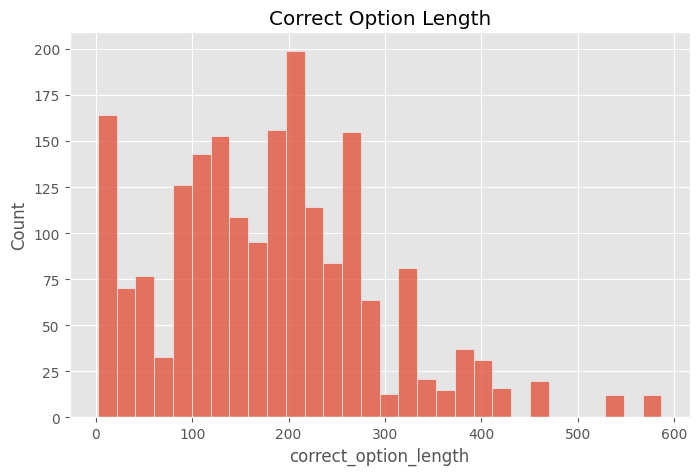

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(
    train["correct_option_length"],
    bins=30
)

plt.title("Correct Option Length")
plt.show()

In [18]:
correct_lengths = []

wrong_lengths = []

for _, row in train.iterrows():

    ans = row["answer"]

    for op in ["A","B","C","D","E"]:

        if op == ans:
            correct_lengths.append(len(str(row[op])))
        else:
            wrong_lengths.append(len(str(row[op])))

print(np.mean(correct_lengths))
print(np.mean(wrong_lengths))

181.879
160.712375


## Topic Analysis 

In [19]:
from collections import Counter
import re

all_text = " ".join(train["prompt"])

words = re.findall(r"\b[a-zA-Z]{4,}\b", all_text.lower())

Counter(words).most_common(50)

[('what', 1809),
 ('correct', 1175),
 ('following', 746),
 ('answer', 608),
 ('option', 608),
 ('from', 442),
 ('based', 414),
 ('which', 399),
 ('among', 388),
 ('listed', 388),
 ('options', 388),
 ('context', 388),
 ('given', 376),
 ('choices', 369),
 ('carefully', 329),
 ('possible', 323),
 ('accurate', 322),
 ('most', 321),
 ('determine', 319),
 ('pick', 316),
 ('best', 316),
 ('select', 309),
 ('identify', 302),
 ('statement', 302),
 ('choose', 292),
 ('between', 240),
 ('relationship', 148),
 ('that', 125),
 ('reason', 103),
 ('used', 102),
 ('effect', 95),
 ('significance', 91),
 ('observed', 85),
 ('statements', 82),
 ('quantum', 72),
 ('accurately', 71),
 ('symmetry', 69),
 ('main', 68),
 ('physics', 67),
 ('space', 64),
 ('describes', 62),
 ('function', 59),
 ('definition', 59),
 ('time', 57),
 ('with', 56),
 ('redshift', 56),
 ('light', 55),
 ('mechanics', 54),
 ('role', 50),
 ('galaxy', 50)]

In [20]:
for idx in range(5):

    row = train.iloc[idx]

    print("="*100)
    print("QUESTION")
    print(row["prompt"])

    print()

    for option in ["A","B","C","D","E"]:

        print(option, ":", row[option])

    print()
    print("ANSWER:", row["answer"])

QUESTION
Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.

A : Martin Heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. The relationship to the past involves acknowledging it as a historical era, and the relationship to the future involves creating a world that will endure beyond one's own time.
B : Martin Heidegger believes that humans do not exist inside time, but that they are time. The relationship to the past is a present awareness of having been, and the relationship to the future involves anticipating a potential possibility, task, or engagement.
C : Martin Heidegger does not believe in the existence of time or that it has any effect on human consciousness. The relationship to the past and the future is insignificant, and human existence is solely based on the present.
D : Martin Heidegger believes that the relati

# Initial Modeling Insights

1. Questions and answer choices are relatively long.
2. Transformer architectures are likely to perform well.
3. Stratified KFold validation should be used.
4. Duplicate prompts should be investigated further.
5. Option-ranking formulation may outperform simple multiclass classification.

Planned Models:
- DeBERTa-v3 (Primary Model)
- BiLSTM + Attention (Custom Model)
- TF-IDF + XGBoost (Classical Baseline)

## Final EDA Insights

1. The dataset contains 2000 training questions and 500 test questions.

2. No missing values were found.

3. The dataset is mildly imbalanced, with answers B and C appearing more frequently.

4. Prompts and answer choices are relatively long, suggesting that semantic understanding is required.

5. Duplicate questions exist and are generated through prompt templates such as:
   - "Choose the correct answer"
   - "Identify the correct statement"
   - "Select the most accurate option"

6. Duplicate questions consistently map to the same answer.

7. Because duplicates exist, grouped validation strategies should be investigated to avoid data leakage.

8. The diversity of domains (physics, astronomy, philosophy, material science, etc.) suggests that pretrained language models will likely outperform models trained from scratch.

9. A ranking formulation using Question–Option pairs appears more suitable than direct multiclass classification.